In [0]:
%pip install statsforecast
dbutils.library.restartPython()

Looking in indexes: [REDACTED]
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
dbutils.widgets.text("catalog", "fiap_analytics")
dbutils.widgets.text("schema_ml", "ml")

CATALOG   = dbutils.widgets.get("catalog")
SCHEMA_ML = dbutils.widgets.get("schema_ml")
G  = f"{CATALOG}.gold"
S  = f"{CATALOG}.silver.incidentes"
ML = f"{CATALOG}.{SCHEMA_ML}"

spark.sql(f"CREATE SCHEMA IF NOT EXISTS {ML}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


print(f"Schema ML: {ML}")

Schema ML: fiap_analytics.ml


Dias: 1,095 | de 2023-01-02 a 2025-12-31


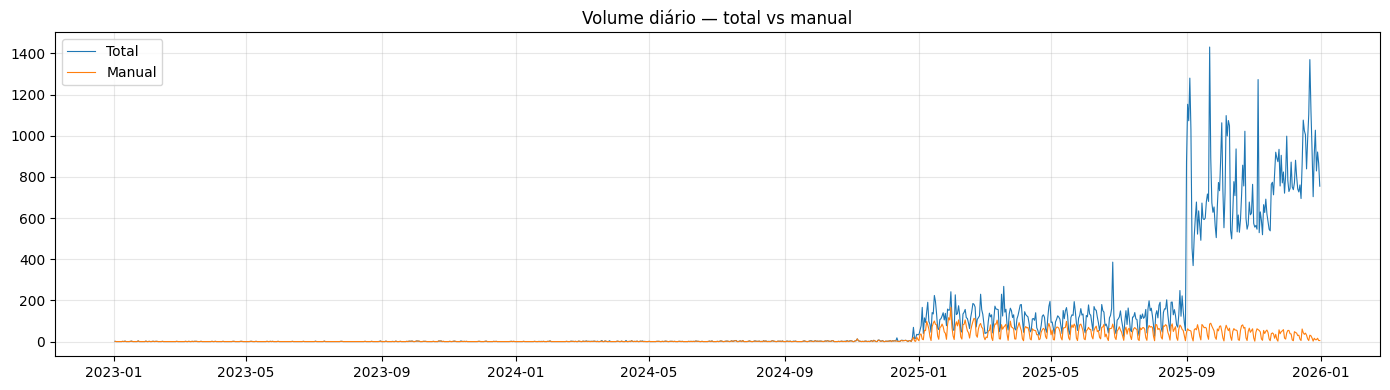

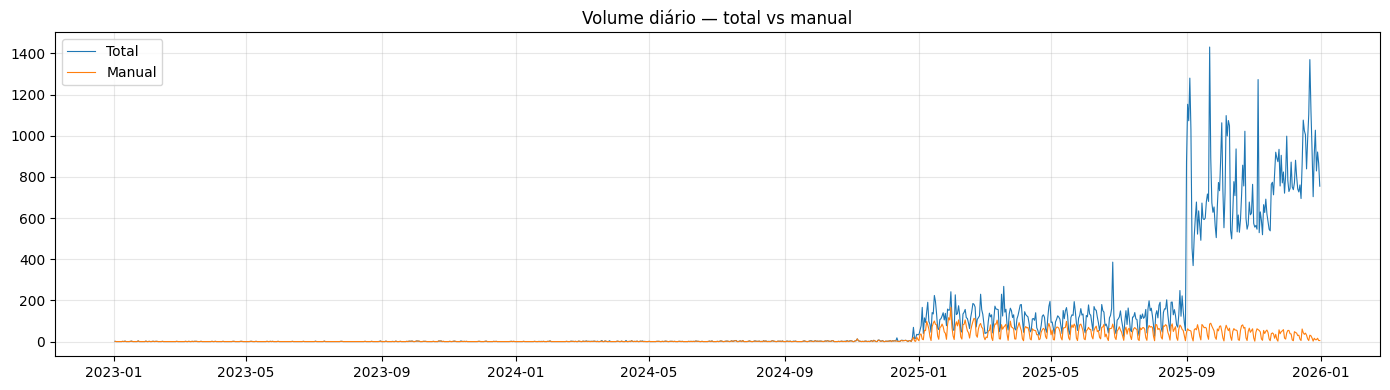

In [0]:
# Duas contagens por dia: TOTAL (tudo) e MANUAL (sem monitoramento).
# dim_tempo garante todos os dias do calendário, mesmo os sem chamado (qtd=0).
serie = spark.sql(f"""
WITH cont AS (
  SELECT dt_abertura AS data,
         count(*)                                                        AS qtd_total,
         sum(CASE WHEN origem_abertura <> 'Monitoramento' THEN 1 ELSE 0 END) AS qtd_manual
  FROM {S}
  GROUP BY dt_abertura
)
SELECT t.data,
       coalesce(c.qtd_total, 0)  AS qtd_total,
       coalesce(c.qtd_manual, 0) AS qtd_manual
FROM {G}.dim_tempo t
LEFT JOIN cont c ON c.data = t.data
WHERE t.data BETWEEN (SELECT min(data) FROM cont) AND (SELECT max(data) FROM cont)
ORDER BY t.data
""").toPandas()

serie['data'] = pd.to_datetime(serie['data'])
print(f"Dias: {len(serie):,} | de {serie.data.min().date()} a {serie.data.max().date()}")

fig, ax = plt.subplots(figsize=(14,4))
ax.plot(serie.data, serie.qtd_total,  lw=.8, label='Total')
ax.plot(serie.data, serie.qtd_manual, lw=.8, label='Manual')
ax.legend(); ax.grid(alpha=.3)
ax.set_title('Volume diário — total vs manual')
plt.tight_layout(); display(fig)

In [0]:
# statsforecast usa 'unique_id' pra distinguir séries. Empilhamos as duas
# (total e manual) numa tabela só, com id diferente — ele treina as duas de uma vez.
def para_sf(df, coluna, uid):
    d = df[['data', coluna]].rename(columns={'data':'ds', coluna:'y'}).copy()
    d['unique_id'] = uid
    return d[['unique_id','ds','y']]

df_sf = pd.concat([
    para_sf(serie, 'qtd_total',  'total'),
    para_sf(serie, 'qtd_manual', 'manual'),
], ignore_index=True)

DIAS_TESTE = 60
corte = df_sf.ds.max() - pd.Timedelta(days=DIAS_TESTE)
treino = df_sf[df_sf.ds <= corte]
teste  = df_sf[df_sf.ds >  corte]
print(f"Treino: {len(treino):,} linhas | Teste: {len(teste):,} linhas (2 séries)")

Treino: 2,070 linhas | Teste: 120 linhas (2 séries)


In [0]:
from statsforecast import StatsForecast
from statsforecast.models import AutoETS, SeasonalNaive

sf = StatsForecast(
    models=[AutoETS(season_length=7), SeasonalNaive(season_length=7)],
    freq='D', n_jobs=-1
)
sf.fit(treino)

prev = sf.predict(h=DIAS_TESTE)
prev = prev.merge(teste, on=['unique_id','ds'], how='left')
display(prev.head())

Exception occurred during shutdown callback <function SparkConnectHook._register_shutdown_hook.<locals>.shutdown_hook at 0xff65caff09a0>:
Traceback (most recent call last):
  File "/databricks/python_shell/lib/dbruntime/kernel.py", line 73, in _run_shutdown_callbacks
    cb()
  File "/databricks/python_shell/lib/dbruntime/serverless/SparkConnectHook.py", line 408, in shutdown_hook
    client.release_session()
  File "/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/client/core.py", line 2279, in release_session
    self._handle_error(error)
  File "/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/client/core.py", line 2381, in _handle_error
    raise error
  File "/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/client/core.py", line 2274, in release_session
    resp = self._stub.ReleaseSession(req, metadata=self.metadata())
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3

unique_id,ds,AutoETS,SeasonalNaive,y
manual,2025-11-02T00:00:00.000Z,1.7733291,5.0,2
manual,2025-11-03T00:00:00.000Z,51.87146,49.0,45
manual,2025-11-04T00:00:00.000Z,66.81344,65.0,62
manual,2025-11-05T00:00:00.000Z,59.239384,45.0,58
manual,2025-11-06T00:00:00.000Z,57.984985,54.0,54


In [0]:
from sklearn.metrics import mean_absolute_error

for uid in ['total','manual']:
    p = prev[prev.unique_id == uid]
    mae_ets   = mean_absolute_error(p.y, p['AutoETS'])
    mae_naive = mean_absolute_error(p.y, p['SeasonalNaive'])
    ganho = 100*(mae_naive - mae_ets)/mae_naive
    print(f"[{uid.upper():6}] MAE AutoETS: {mae_ets:5.1f} | "
          f"MAE Naive: {mae_naive:5.1f} | Ganho AutoETS: {ganho:+.1f}%")

[TOTAL ] MAE AutoETS: 155.7 | MAE Naive: 205.1 | Ganho AutoETS: +24.1%
[MANUAL] MAE AutoETS:  15.8 | MAE Naive:  14.4 | Ganho AutoETS: -9.9%


In [0]:
# ── Previsão REAL de futuro: treina em toda a série, projeta 7 dias à frente ──
# Diferente do backtest, aqui não há "real" — é o futuro (D+1 a D+7).
sf_fut = StatsForecast(
    models=[AutoETS(season_length=7), SeasonalNaive(season_length=7)],
    freq='D', n_jobs=-1
)
sf_fut.fit(df_sf)                      # treina em TUDO
futuro = sf_fut.predict(h=7)           # D+1 até D+7

fut = (futuro.rename(columns={'AutoETS':'previsto','SeasonalNaive':'baseline'})
             .assign(horizonte=lambda d: d.groupby('unique_id').cumcount()+1))  # 1=D+1 ... 7=D+7
fut['data'] = fut.ds.dt.date
for c in ['previsto','baseline']:
    fut[c] = fut[c].round().clip(lower=0).astype(int)

display(fut.sort_values(['unique_id','ds']))

Exception occurred during shutdown callback <function SparkConnectHook._register_shutdown_hook.<locals>.shutdown_hook at 0xff65caff09a0>:
Traceback (most recent call last):
  File "/databricks/python_shell/lib/dbruntime/kernel.py", line 73, in _run_shutdown_callbacks
    cb()
  File "/databricks/python_shell/lib/dbruntime/serverless/SparkConnectHook.py", line 408, in shutdown_hook
    client.release_session()
  File "/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/client/core.py", line 2279, in release_session
    self._handle_error(error)
  File "/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/client/core.py", line 2381, in _handle_error
    raise error
  File "/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/client/core.py", line 2274, in release_session
    resp = self._stub.ReleaseSession(req, metadata=self.metadata())
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3

unique_id,ds,previsto,baseline,horizonte,data
manual,2026-01-01T00:00:00.000Z,10,2,1,2026-01-01
manual,2026-01-02T00:00:00.000Z,15,16,2,2026-01-02
manual,2026-01-03T00:00:00.000Z,0,9,3,2026-01-03
manual,2026-01-04T00:00:00.000Z,0,9,4,2026-01-04
manual,2026-01-05T00:00:00.000Z,18,16,5,2026-01-05
manual,2026-01-06T00:00:00.000Z,13,5,6,2026-01-06
manual,2026-01-07T00:00:00.000Z,12,5,7,2026-01-07
total,2026-01-01T00:00:00.000Z,769,704,1,2026-01-01
total,2026-01-02T00:00:00.000Z,787,910,2,2026-01-02
total,2026-01-03T00:00:00.000Z,701,1027,3,2026-01-03


In [0]:
import mlflow

mlflow.set_experiment(f"/Users/{spark.sql('SELECT current_user()').first()[0]}/fiap_previsao_volume")

for uid in ['total', 'manual']:
    p = prev[prev.unique_id == uid]
    mae_ets   = mean_absolute_error(p.y, p['AutoETS'])
    mae_naive = mean_absolute_error(p.y, p['SeasonalNaive'])

    with mlflow.start_run(run_name=f"volume_{uid}"):
        mlflow.log_param("serie", uid)
        mlflow.log_param("modelo", "AutoETS + SeasonalNaive")
        mlflow.log_param("season_length", 7)
        mlflow.log_param("dias_teste", DIAS_TESTE)
        mlflow.log_metric("mae_autoets", mae_ets)
        mlflow.log_metric("mae_seasonal_naive", mae_naive)
        mlflow.log_metric("ganho_pct_autoets", 100*(mae_naive - mae_ets)/mae_naive)
        print(f"[{uid}] registrado: AutoETS={mae_ets:.1f}, Naive={mae_naive:.1f}")

[total] registrado: AutoETS=155.7, Naive=205.1
[manual] registrado: AutoETS=15.8, Naive=14.4


In [0]:
from pyspark.sql import functions as F

fut_sdf = spark.createDataFrame(
    fut[['unique_id','data','horizonte','previsto','baseline']]
).withColumn('dt_geracao', F.current_timestamp())

(fut_sdf.write.format("delta").mode("overwrite").option("overwriteSchema","true")
        .saveAsTable(f"{ML}.previsao_futuro"))

print(f"{len(fut):,} linhas gravadas em {ML}.previsao_futuro")
display(spark.sql(f"SELECT * FROM {ML}.previsao_futuro ORDER BY unique_id, horizonte"))

14 linhas gravadas em fiap_analytics.ml.previsao_futuro


unique_id,data,horizonte,previsto,baseline,dt_geracao
manual,2026-01-01,1,10,2,2026-08-29T15:57:09.637Z
manual,2026-01-02,2,15,16,2026-08-29T15:57:09.637Z
manual,2026-01-03,3,0,9,2026-08-29T15:57:09.637Z
manual,2026-01-04,4,0,9,2026-08-29T15:57:09.637Z
manual,2026-01-05,5,18,16,2026-08-29T15:57:09.637Z
manual,2026-01-06,6,13,5,2026-08-29T15:57:09.637Z
manual,2026-01-07,7,12,5,2026-08-29T15:57:09.637Z
total,2026-01-01,1,769,704,2026-08-29T15:57:09.637Z
total,2026-01-02,2,787,910,2026-08-29T15:57:09.637Z
total,2026-01-03,3,701,1027,2026-08-29T15:57:09.637Z


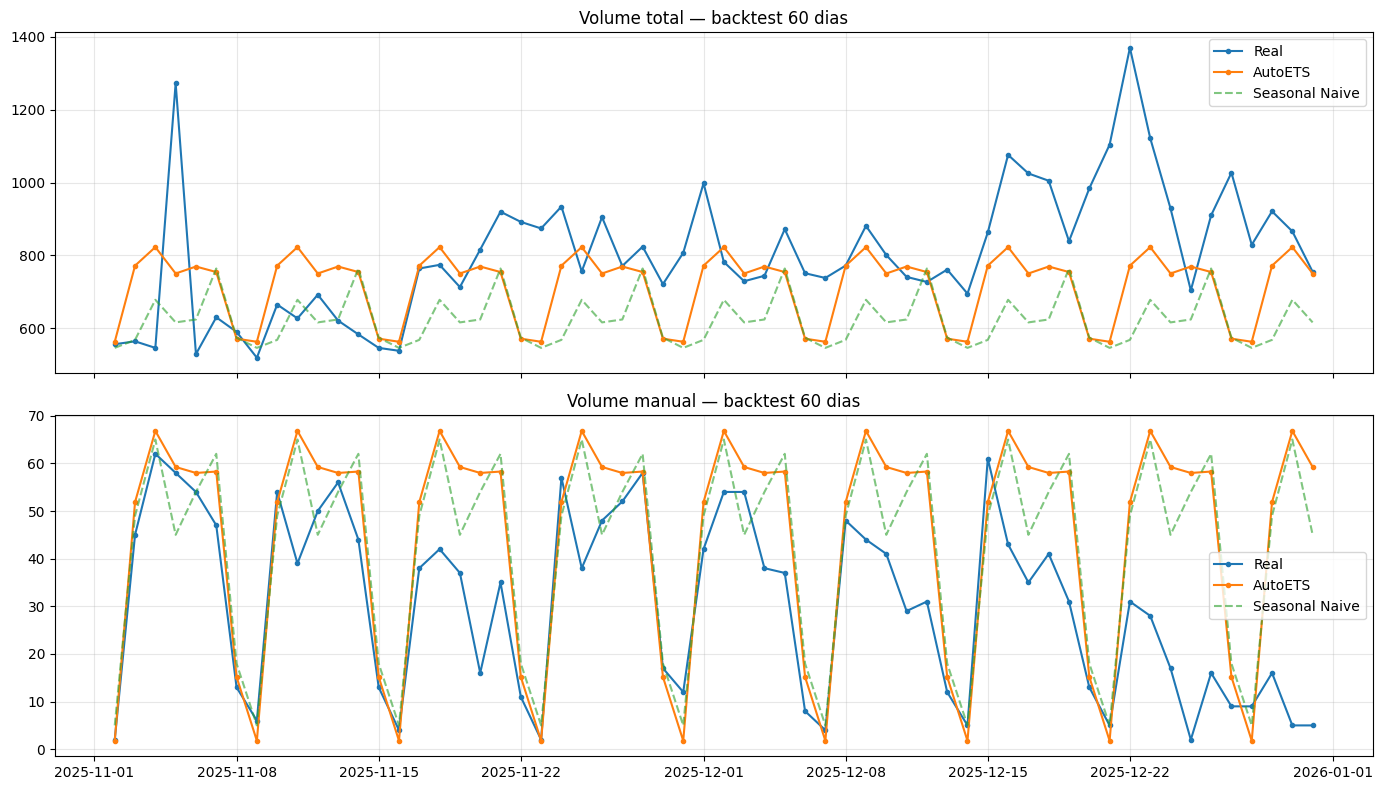

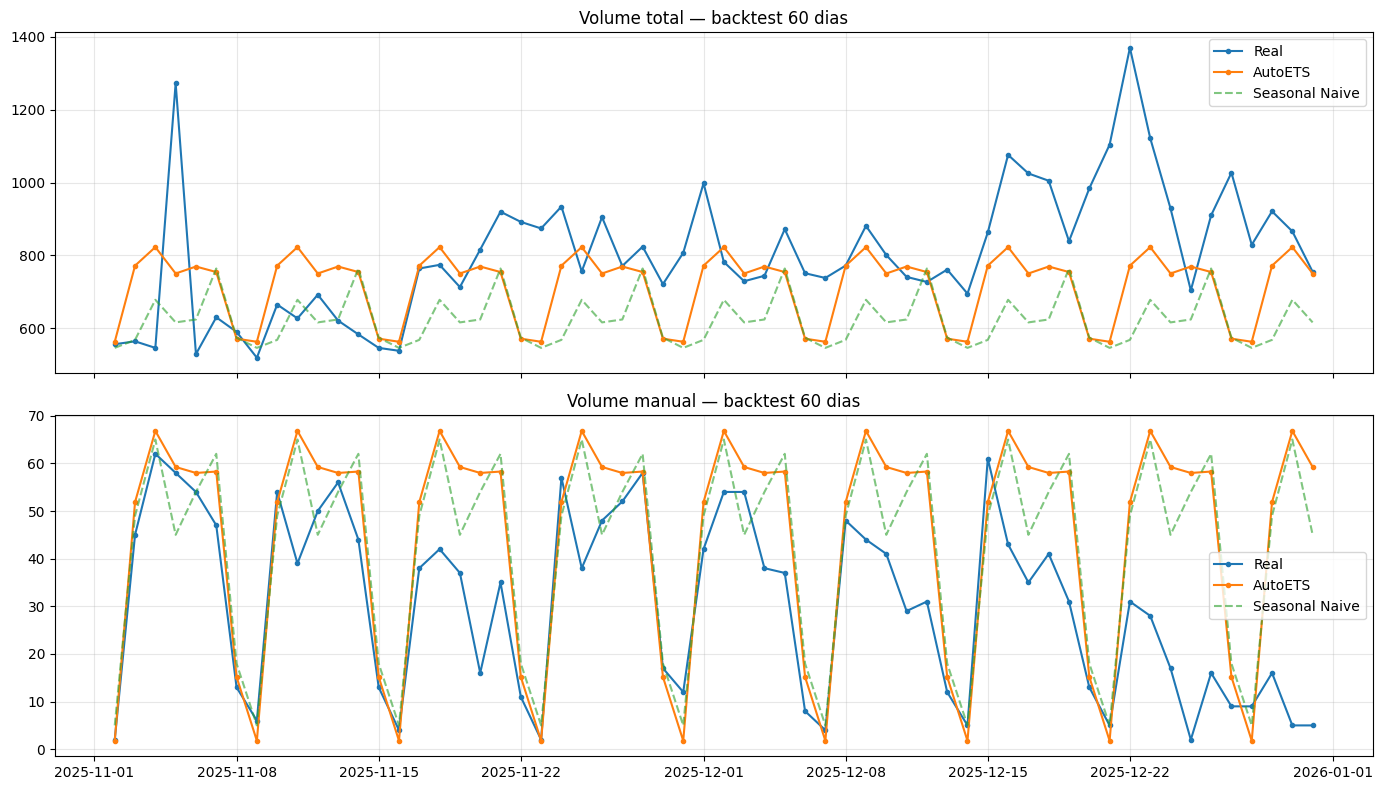

In [0]:
fig, ax = plt.subplots(2, 1, figsize=(14,8), sharex=True)
for i, uid in enumerate(['total','manual']):
    p = prev[prev.unique_id == uid]
    ax[i].plot(p.ds, p.y,             marker='.', label='Real')
    ax[i].plot(p.ds, p['AutoETS'],    marker='.', label='AutoETS')
    ax[i].plot(p.ds, p['SeasonalNaive'], ls='--', alpha=.6, label='Seasonal Naive')
    ax[i].set_title(f'Volume {uid} — backtest 60 dias')
    ax[i].legend(); ax[i].grid(alpha=.3)
plt.tight_layout(); display(fig)

In [0]:
# Pivota: uma linha por data, colunas separadas para total e manual.
p_total  = prev[prev.unique_id=='total'][['ds','y','AutoETS','SeasonalNaive']]
p_manual = prev[prev.unique_id=='manual'][['ds','y','AutoETS','SeasonalNaive']]

saida = (p_total.rename(columns={
            'y':'real_total',
            'AutoETS':'previsto_total',
            'SeasonalNaive':'baseline_total'})
         .merge(
         p_manual.rename(columns={
            'y':'real_manual',
            'AutoETS':'previsto_manual',
            'SeasonalNaive':'baseline_manual'}),
         on='ds'))

saida['data'] = saida.ds.dt.date
for c in ['previsto_total','baseline_total','previsto_manual','baseline_manual']:
    saida[c] = saida[c].round().clip(lower=0).astype(int)
for c in ['real_total','real_manual']:
    saida[c] = saida[c].astype(int)

saida['dt_geracao'] = pd.Timestamp.now()
saida = saida[['data','real_total','previsto_total','baseline_total',
               'real_manual','previsto_manual','baseline_manual','dt_geracao']]
display(saida.head())

data,real_total,previsto_total,baseline_total,real_manual,previsto_manual,baseline_manual,dt_geracao
2025-11-02,556,563,546,2,2,5,2026-08-29T15:57:16.120Z
2025-11-03,564,772,568,45,52,49,2026-08-29T15:57:16.120Z
2025-11-04,546,823,678,62,67,65,2026-08-29T15:57:16.120Z
2025-11-05,1273,750,616,58,59,45,2026-08-29T15:57:16.120Z
2025-11-06,529,769,624,54,58,54,2026-08-29T15:57:16.120Z


In [0]:
prev_sdf = (spark.createDataFrame(saida)
    .join(spark.table(f"{G}.dim_tempo").select('sk_tempo','data'), on='data', how='left'))

(prev_sdf.write.format("delta").mode("overwrite").option("overwriteSchema","true")
         .saveAsTable(f"{ML}.previsao_volume"))

print(f"{len(saida):,} dias gravados em {ML}.previsao_volume")
display(spark.sql(f"SELECT * FROM {ML}.previsao_volume ORDER BY data LIMIT 10"))

60 dias gravados em fiap_analytics.ml.previsao_volume


data,real_total,previsto_total,baseline_total,real_manual,previsto_manual,baseline_manual,dt_geracao,sk_tempo
2025-11-02,556,563,546,2,2,5,2026-08-29T15:57:16.120Z,20251102
2025-11-03,564,772,568,45,52,49,2026-08-29T15:57:16.120Z,20251103
2025-11-04,546,823,678,62,67,65,2026-08-29T15:57:16.120Z,20251104
2025-11-05,1273,750,616,58,59,45,2026-08-29T15:57:16.120Z,20251105
2025-11-06,529,769,624,54,58,54,2026-08-29T15:57:16.120Z,20251106
2025-11-07,630,754,764,47,58,62,2026-08-29T15:57:16.120Z,20251107
2025-11-08,590,571,574,13,15,18,2026-08-29T15:57:16.120Z,20251108
2025-11-09,519,563,546,6,2,5,2026-08-29T15:57:16.120Z,20251109
2025-11-10,665,772,568,54,52,49,2026-08-29T15:57:16.120Z,20251110
2025-11-11,627,823,678,39,67,65,2026-08-29T15:57:16.120Z,20251111


In [0]:
display(spark.sql(f"""
WITH
-- universo: pares (ativo, dia) possíveis, só do regime com volume (set/2025+)
dias_auto AS (
  SELECT DISTINCT item_configuracao, dt_abertura AS dia
  FROM {S}
  WHERE origem_abertura = 'Monitoramento'
    AND item_configuracao IS NOT NULL
    AND dt_abertura >= '2025-09-01'
),
manuais AS (
  SELECT item_configuracao, dt_abertura AS data_manual
  FROM {S}
  WHERE origem_abertura <> 'Monitoramento'
    AND item_configuracao IS NOT NULL
    AND dt_abertura >= '2025-09-01'
),
-- taxa de chamado manual QUANDO houve alerta nos 30d anteriores
com_alerta AS (
  SELECT m.item_configuracao, m.data_manual,
         CASE WHEN EXISTS (
           SELECT 1 FROM dias_auto a
           WHERE a.item_configuracao = m.item_configuracao
             AND a.dia BETWEEN m.data_manual - INTERVAL 30 DAYS
                           AND m.data_manual - INTERVAL 1 DAY
         ) THEN 1 ELSE 0 END AS teve_alerta
  FROM manuais m
)
SELECT
  count(*)                                          AS total_manuais,
  sum(teve_alerta)                                  AS precedidos_alerta,
  round(100.0*sum(teve_alerta)/count(*), 1)         AS pct_precedido,
  (SELECT count(DISTINCT item_configuracao) FROM dias_auto)   AS ativos_com_alerta,
  (SELECT count(DISTINCT item_configuracao) FROM manuais)     AS ativos_com_manual
FROM com_alerta
"""))

total_manuais,precedidos_alerta,pct_precedido,ativos_com_alerta,ativos_com_manual
4886,2070,42.4,5714,1381


In [0]:
display(spark.sql(f"""
WITH auto_ativos AS (
  SELECT DISTINCT item_configuracao AS ci
  FROM {S}
  WHERE origem_abertura = 'Monitoramento' AND item_configuracao IS NOT NULL
    AND dt_abertura >= '2025-09-01'
),
manual_ativos AS (
  SELECT DISTINCT item_configuracao AS ci
  FROM {S}
  WHERE origem_abertura <> 'Monitoramento' AND item_configuracao IS NOT NULL
    AND dt_abertura >= '2025-09-01'
),
classificado AS (
  SELECT a.ci,
         CASE WHEN m.ci IS NOT NULL THEN 1 ELSE 0 END AS deu_manual
  FROM auto_ativos a
  LEFT JOIN manual_ativos m ON a.ci = m.ci
)
SELECT
  count(*)                                    AS ativos_que_alertaram,
  sum(deu_manual)                             AS alertaram_e_deram_manual,
  sum(1 - deu_manual)                         AS alertaram_mas_nunca_manual,
  round(100.0*sum(deu_manual)/count(*), 1)    AS pct_alerta_virou_manual
FROM classificado
"""))

ativos_que_alertaram,alertaram_e_deram_manual,alertaram_mas_nunca_manual,pct_alerta_virou_manual
5714,703,5011,12.3


In [0]:
display(spark.sql(f"""
SELECT
  count(*)                                              AS total,
  count(dt_aberto)                                      AS tem_aberto,
  count(dt_resolvido)                                   AS tem_resolvido,
  count(dt_encerrado)                                   AS tem_encerrado,
  sum(CASE WHEN dt_resolvido IS NOT NULL
            AND dt_aberto IS NOT NULL THEN 1 ELSE 0 END) AS tem_os_dois
FROM {S}
WHERE fl_entrou_kpi = true
"""))

total,tem_aberto,tem_resolvido,tem_encerrado,tem_os_dois
25600,25600,25042,25600,25042
